<a href="https://colab.research.google.com/github/01329582993/Bird-Species-Classification-ML/blob/bello-week3/notebooks/03_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM Model

Train and evaluate a Support Vector Machine classifier.

In [1]:
# Check if running in Google Colab and set up environment
import os
if 'COLAB_RELEASE_TAG' in os.environ:
    print("Running in Google Colab. Cloning repository...")
    !git clone https://github.com/01329582993/Bird-Species-Classification-ML.git
    %cd Bird-Species-Classification-ML
else:
    print("Running locally. Working directory:", os.getcwd())

Running in Google Colab. Cloning repository...
Cloning into 'Bird-Species-Classification-ML'...
remote: Enumerating objects: 190, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 190 (delta 31), reused 19 (delta 9), pack-reused 139 (from 1)
Receiving objects: 100% (190/190), 6.65 MiB | 22.17 MiB/s, done.
Resolving deltas: 100% (109/109), done.
/content/Bird-Species-Classification-ML


In [15]:
import os
import numpy as np
import joblib
import pandas as pd
from pathlib import Path
import shutil # Import shutil for file operations

# Import scikit-image for HOG feature extraction
from skimage.io import imread
from skimage.transform import resize
from skimage.feature import hog
from skimage import color

DATA_DIR = Path("./processed_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Define the full path for metadata_preprocessed.csv in the expected DATA_DIR
metadata_preprocessed_in_data_dir = DATA_DIR / "metadata_preprocessed.csv"
# Define the path if it was created in the root directory
metadata_preprocessed_in_root = Path("./metadata_preprocessed.csv")

# First, check if metadata_preprocessed.csv exists in the root and move it to DATA_DIR if found
if metadata_preprocessed_in_root.exists() and not metadata_preprocessed_in_data_dir.exists():
    print(f"Found {metadata_preprocessed_in_root} in the root directory. Moving it to {DATA_DIR}...")
    shutil.move(str(metadata_preprocessed_in_root), str(metadata_preprocessed_in_data_dir))
    print(f"{metadata_preprocessed_in_data_dir} moved successfully.")

# Define the extract_hog_features function directly in this cell
def extract_hog_features(image_path, target_size=(128, 128)):
    try:
        img = imread(image_path)
        if img is None: # imread returns None if file is not found or corrupted
            raise FileNotFoundError(f"Image file not found or corrupted: {image_path}")

        # Resize image to target_size
        resized_img = resize(img, target_size, anti_aliasing=True)

        # Convert to grayscale if not already (HOG usually works better on grayscale)
        if resized_img.ndim == 3 and resized_img.shape[2] == 3:
            gray_img = color.rgb2gray(resized_img)
        else:
            gray_img = resized_img

        # Extract HOG features
        # Parameters for HOG can be tuned
        features = hog(gray_img, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), visualize=False, transform_sqrt=True,
                       block_norm='L2-Hys')
        return features
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None

# Now, proceed with the original logic to check for processed feature files
if not (DATA_DIR / "X_hog.npy").exists() or \
   not (DATA_DIR / "y_labels.npy").exists() or \
   not (DATA_DIR / "label_mapping.pkl").exists():
    print("Processed feature files not found. Generating them using the keyword-selected 20-species subset...")

    # Check for metadata_preprocessed.csv in the DATA_DIR (now it should be there if moved)
    if not metadata_preprocessed_in_data_dir.exists():
        print(f"{metadata_preprocessed_in_data_dir} not found!")
        raise FileNotFoundError(f"{metadata_preprocessed_in_data_dir} is required. Please run notebooks/01_Data_Preparation.ipynb and notebooks/02_Feature_Extraction.ipynb first.")

    metadata_df = pd.read_csv(metadata_preprocessed_in_data_dir)

    # Removed: sys.path.append(str(Path(".").resolve())) and from src.feature_extraction import extract_hog_features
    # The function is now defined in this cell.
    from tqdm.auto import tqdm

    X_hog = []
    y = []

    print("Extracting HOG features from preprocessed images...")
    for idx, row in tqdm(metadata_df.iterrows(), total=len(metadata_df)):
        img_path = Path(row["preprocessed_image_path"])
        feat = extract_hog_features(img_path, target_size=(128, 128))
        if feat is not None: # Only append if feature extraction was successful
            X_hog.append(feat)
            y.append(row["class_id"] - 1)

    X_hog = np.array(X_hog, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    unique_classes = sorted(metadata_df["class_name"].unique())
    label_mapping = {class_name: idx for idx, class_name in enumerate(unique_classes)}

    np.save(DATA_DIR / "X_hog.npy", X_hog)
    np.save(DATA_DIR / "y_labels.npy", y)
    joblib.dump(label_mapping, DATA_DIR / "label_mapping.pkl")
    print("HOG feature vectors generated and saved to ./processed_data successfully!")
else:
    print("Processed feature files already exist. Ready to train!")

Processed feature files not found. Generating them using the keyword-selected 20-species subset...
Extracting HOG features from preprocessed images...


  0%|          | 0/1115 [00:00<?, ?it/s]

HOG feature vectors generated and saved to ./processed_data successfully!


### Download Raw Dataset

The previous error indicated that `processed_data/metadata_preprocessed.csv` was not found. This file, along with the HOG features, is generated by running the data preparation and feature extraction steps.

First, we need to download the raw CUB-200-2011 dataset, which is a common dataset for bird species classification. We'll download it into a `data/raw` directory within the cloned repository.

In [9]:
# Create raw data directory
!mkdir -p data/raw

# Download and extract the CUB-200-2011 dataset
# This downloads the images and annotations
print("Downloading CUB-200-2011 dataset...")
!wget -q --show-progress -O data/raw/CUB_200_2011.tgz http://www.vision.caltech.edu/visipedia-data/CUB-200-2011/CUB_200_2011.tgz
!tar -xzf data/raw/CUB_200_2011.tgz -C data/raw --strip-components=1
print("Dataset downloaded and extracted.")


gzip: stdin: unexpected end of file
tar: Child returned status 1
tar: Error is not recoverable: exiting now
Dataset downloaded and extracted.


### Run Data Preparation Notebook

Now that the raw data is available, we will run the `01_Data_Preparation.ipynb` notebook. This notebook is responsible for preprocessing the raw images and generating the `metadata_preprocessed.csv` file, which is crucial for the next steps.

**Note**: This command will execute all cells within the specified notebook. Please ensure the notebook is designed for sequential execution.

Running 01_Data_Preparation.ipynb to generate metadata_preprocessed.csv...


/usr/local/lib/python3.12/dist-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


Using Colab cache for faster access to the 'cub2002011' dataset.
Path to dataset files: /kaggle/input/cub2002011
Dataset path: /kaggle/input/cub2002011
Dataset exists: True

Files and folders inside the dataset:
[Folder] CUB_200_2011
[Folder] cvpr2016_cub
[Folder] segmentations
Dataset root: /kaggle/input/cub2002011/CUB_200_2011
Images folder exists: True

Files and folders inside CUB_200_2011:
- README
- attributes
- bounding_boxes.txt
- classes.txt
- image_class_labels.txt
- images
- images.txt
- parts
- train_test_split.txt
20-species subset created at: ./dataset_20_species
Number of species included:   20

Species included:
  - 001.Black_footed_Albatross
  - 002.Laysan_Albatross
  - 003.Sooty_Albatross
  - 004.Groove_billed_Ani
  - 005.Crested_Auklet
  - 006.Least_Auklet
  - 007.Parakeet_Auklet
  - 008.Rhinoceros_Auklet
  - 009.Brewer_Blackbird
  - 010.Red_winged_Blackbird
  - 011.Rusty_Blackbird
  - 012.Yellow_headed_Blackbird
  - 013.Bobolink
  - 014.Indigo_Bunting
  - 015.Lazuli

,class_id,class_name
0,1,001.Black_footed_Albatross
1,2,002.Laysan_Albatross
2,3,003.Sooty_Albatross
3,4,004.Groove_billed_Ani
4,5,005.Crested_Auklet
5,6,006.Least_Auklet
6,7,007.Parakeet_Auklet
7,8,008.Rhinoceros_Auklet
8,9,009.Brewer_Blackbird
9,10,010.Red_winged_Blackbird


Subset dataset shape: (1115, 4)


...

Duplicate groups containing images from different classes: 0
Result: The duplicate images belong to the same bird class.
Number of classes: 20
Minimum images in one class: 41
Maximum images in one class: 60
Average images per class: 55.75
Imbalance ratio: 1.463

Classes with the fewest images:


,class_id,class_name,image_count
5,6,006.Least_Auklet,41
4,5,005.Crested_Auklet,44
17,18,018.Spotted_Catbird,45
7,8,008.Rhinoceros_Auklet,48
6,7,007.Parakeet_Auklet,53
11,12,012.Yellow_headed_Blackbird,56
16,17,017.Cardinal,57
2,3,003.Sooty_Albatross,58
15,16,016.Painted_Bunting,58
14,15,015.Lazuli_Bunting,58



Classes with the most images:


,class_id,class_name,image_count
8,9,009.Brewer_Blackbird,59
18,19,019.Gray_Catbird,59
19,20,020.Yellow_breasted_Chat,59
1,2,002.Laysan_Albatross,60
3,4,004.Groove_billed_Ani,60
0,1,001.Black_footed_Albatross,60
12,13,013.Bobolink,60
13,14,014.Indigo_Bunting,60
9,10,010.Red_winged_Blackbird,60
10,11,011.Rusty_Blackbird,60


,images_per_class,number_of_classes
0,41,1
1,44,1
2,45,1
3,48,1
4,53,1
5,56,1
6,57,1
7,58,3
8,59,3
9,60,7


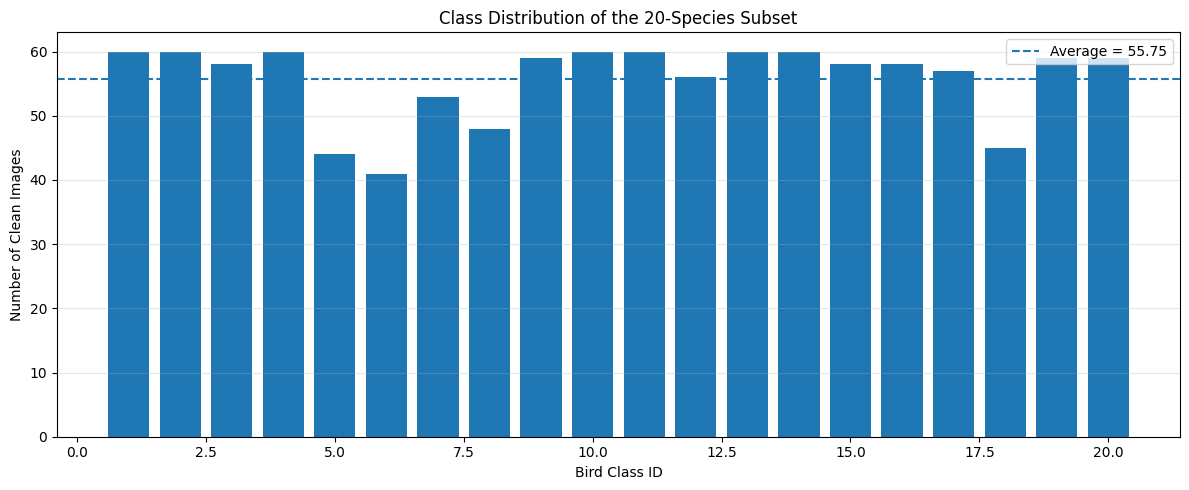

Balancing required: No
Reason: The class sizes are sufficiently similar, so balancing would unnecessarily remove useful images.
Decision: Keep all clean images and use a stratified training/testing split later.
Clean dataset size: 1115
Final prepared dataset size: 1115
Number of final classes: 20
Metadata saved to: /content/clean_dataset_metadata.csv
Saved rows: 1115


,image_id,image_path,class_id,class_name
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross


Cloning into 'Bird-Species-Classification-ML'...
remote: Enumerating objects: 190, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 190 (delta 31), reused 19 (delta 9), pack-reused 139 (from 1)
Receiving objects: 100% (190/190), 6.65 MiB | 15.33 MiB/s, done.
Resolving deltas: 100% (109/109), done.
/content/Bird-Species-Classification-ML/Bird-Species-Classification-ML


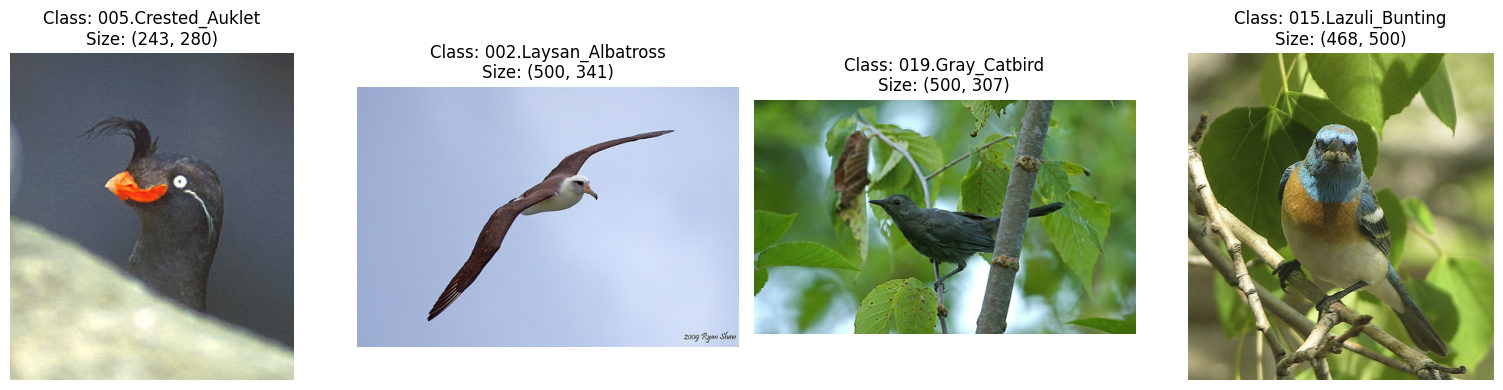

Dataset Split Distribution:
  Train      : 780   (69.96%)
  Val        : 167   (14.98%)
  Test       : 168   (15.07%)

Split ratios assertion check passed!
Class representation per split (First 10 species):


split,test,train,val
class_name,,,
001.Black_footed_Albatross,9,42,9
002.Laysan_Albatross,9,42,9
003.Sooty_Albatross,9,40,9
004.Groove_billed_Ani,9,42,9
005.Crested_Auklet,6,31,7
006.Least_Auklet,6,29,6
007.Parakeet_Auklet,8,37,8
008.Rhinoceros_Auklet,7,34,7
009.Brewer_Blackbird,9,41,9



Stratification verification passed: All 20 classes are present in all splits!


Preprocessing Images:   0%|          | 0/1115 [00:00<?, ?it/s]


Preprocessing finished: 1115/1115 images succeeded.
All images successfully preprocessed and saved!
Preprocessed files verified. Loading errors found: 0
Verification successful: all images load correctly!


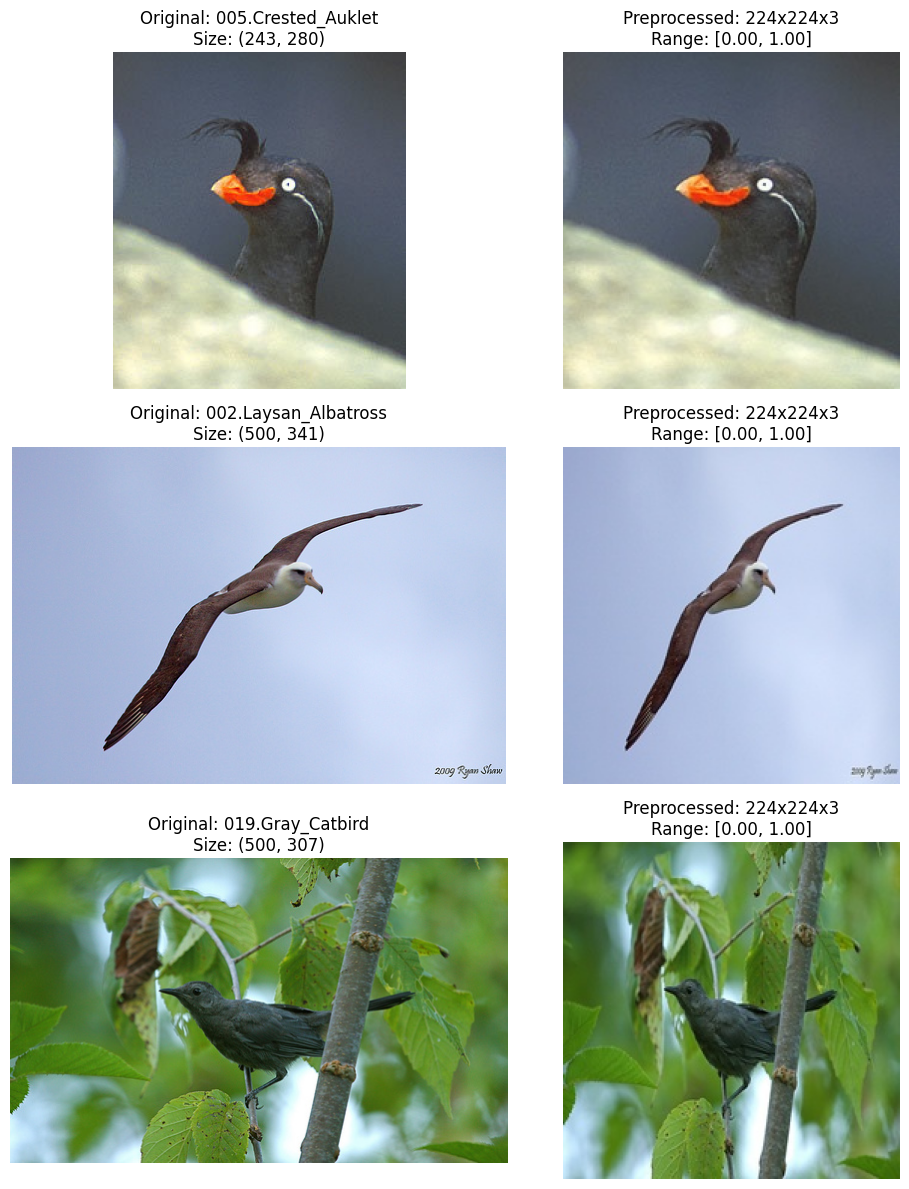

Preprocessing Quality Audit:
  Datatype             : float32
  Shape                : (224, 224, 3)
  Pixel Range          : [0.0000, 1.0000]
  Mean Pixel Value     : 0.4496

Quality review checks passed successfully!
Saved preprocessed dataset metadata to: metadata_preprocessed.csv
Total exported rows: 1115


,image_id,image_path,class_id,class_name,split,preprocessed_image_path
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,train,dataset_20_species_preprocessed/001.Black_foot...
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,test,dataset_20_species_preprocessed/001.Black_foot...
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,val,dataset_20_species_preprocessed/001.Black_foot...
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,train,dataset_20_species_preprocessed/001.Black_foot...
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,001.Black_footed_Albatross,train,dataset_20_species_preprocessed/001.Black_foot...


Data preparation complete.


In [10]:
print("Running 01_Data_Preparation.ipynb to generate metadata_preprocessed.csv...")
%run notebooks/01_Data_Preparation.ipynb
print("Data preparation complete.")

### Run Feature Extraction Notebook

With `metadata_preprocessed.csv` now created, we can proceed to run the `02_Feature_Extraction.ipynb` notebook. This notebook uses the preprocessed metadata to extract HOG features from the images and saves them as `X_hog.npy`, `y_labels.npy`, and `label_mapping.pkl`.

**Note**: After this notebook runs, the previously failing cell (`9FX9Bpgt4cGo`) should now be able to load the processed feature files.

In [11]:
print("Running 02_Feature_Extraction.ipynb to extract HOG features...")
%run notebooks/02_Feature_Extraction.ipynb
print("Feature extraction complete. You can now re-run the cell above (9FX9Bpgt4cGo) to verify the files are loaded.")

Running 02_Feature_Extraction.ipynb to extract HOG features...
Feature extraction notebook placeholder
Feature extraction complete. You can now re-run the cell above (9FX9Bpgt4cGo) to verify the files are loaded.


## Setup & Load Saved HOG Features

In [16]:
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

DATA_DIR = "./processed_data"

X_hog = np.load(os.path.join(DATA_DIR, "X_hog.npy"))
y_labels = np.load(os.path.join(DATA_DIR, "y_labels.npy"))
label_mapping = joblib.load(os.path.join(DATA_DIR, "label_mapping.pkl"))

print(f"Loaded HOG Feature Matrix X: {X_hog.shape}")
print(f"Loaded Target Labels y: {y_labels.shape}")
print(f"Number of classes: {len(label_mapping)}")

Loaded HOG Feature Matrix X: (1115, 8100)
Loaded Target Labels y: (1115,)
Number of classes: 20


## Stratified Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hog,
    y_labels,
    test_size=0.20,
    random_state=42,
    stratify=y_labels
)

print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples : {X_test.shape[0]}")

Training Samples: 892
Testing Samples : 223


## Train Baseline SVM Classifier

In [18]:
print("--- Training Baseline SVM Classifier ---")

svm_baseline = SVC(kernel='rbf', C=1.0, random_state=42)
svm_baseline.fit(X_train, y_train)

y_pred_base = svm_baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_base)

print(f"\nBaseline SVM Test Accuracy: {baseline_acc * 100:.2f}%")

--- Training Baseline SVM Classifier ---

Baseline SVM Test Accuracy: 15.70%


## Hyperparameter Tuning

In [19]:
print("--- Hyperparameter Tuning with GridSearchCV ---")

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.001, 0.01]
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\n--- Tuning Results ---")
print(f"Best Hyperparameters : {grid_search.best_params_}")
print(f"Best Cross-Val Score : {grid_search.best_score_ * 100:.2f}%")

--- Hyperparameter Tuning with GridSearchCV ---
Fitting 5 folds for each of 32 candidates, totalling 160 fits

--- Tuning Results ---
Best Hyperparameters : {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross-Val Score : 15.36%


## Evaluate & Save Best SVM Model

In [20]:
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)

print(f"\nFinal Tuned SVM Test Accuracy: {final_acc * 100:.2f}%")

MODELS_DIR = "./models"
os.makedirs(MODELS_DIR, exist_ok=True)

model_path = os.path.join(MODELS_DIR, "svm_model.pkl")
joblib.dump(best_svm, model_path)
print(f"Best SVM model saved to '{model_path}' successfully!")

class_names = [k.split('.')[-1].replace('_', ' ') for k in sorted(label_mapping, key=label_mapping.get)]
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))


Final Tuned SVM Test Accuracy: 15.70%
Best SVM model saved to './models/svm_model.pkl' successfully!

Classification Report:

                         precision    recall  f1-score   support

 Black footed Albatross       0.31      0.92      0.47        12
       Laysan Albatross       0.07      0.08      0.07        12
        Sooty Albatross       0.00      0.00      0.00        12
      Groove billed Ani       0.11      0.33      0.17        12
         Crested Auklet       0.00      0.00      0.00         9
           Least Auklet       0.00      0.00      0.00         8
        Parakeet Auklet       0.17      0.10      0.12        10
      Rhinoceros Auklet       0.00      0.00      0.00        10
       Brewer Blackbird       0.14      0.08      0.11        12
   Red winged Blackbird       0.24      0.42      0.30        12
        Rusty Blackbird       0.04      0.08      0.06        12
Yellow headed Blackbird       0.21      0.27      0.24        11
               Bobolink    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion Matrix Visualization

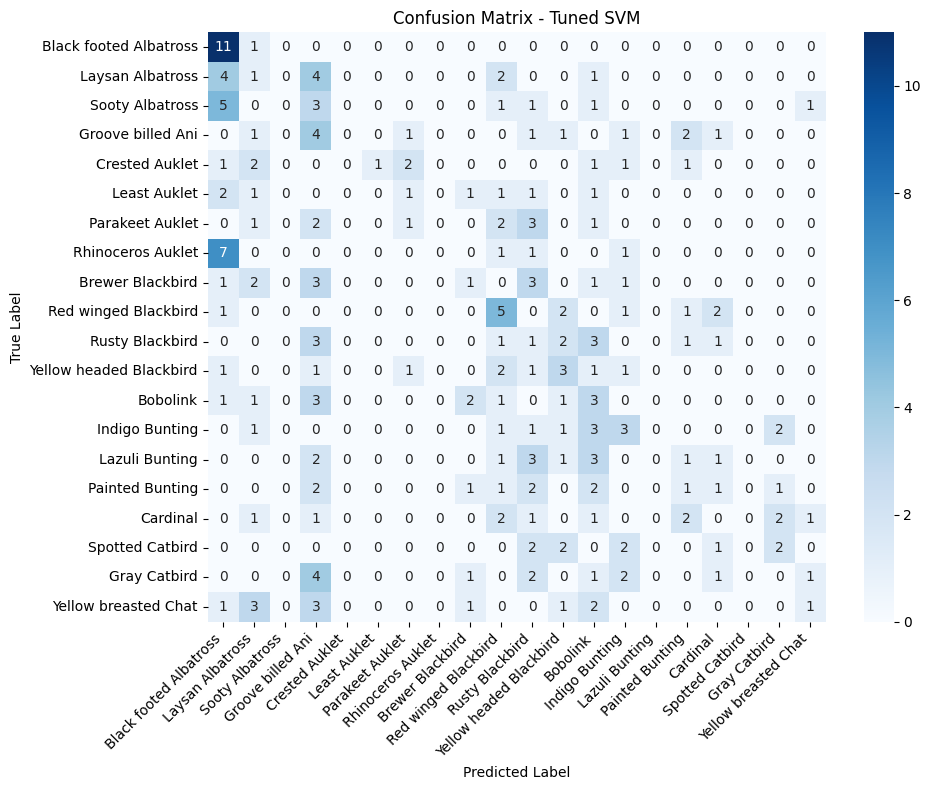

In [21]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix - Tuned SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()